# Iris Plant Prediction

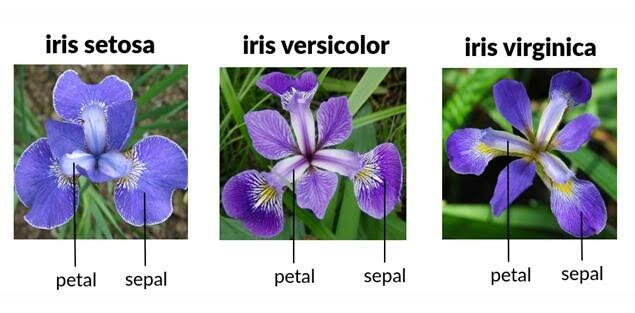

### Importing required libraries

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

Each instance represents a single iris plant with four numeric features measured in centimeters: sepal length, sepal width, petal length, and petal width.The class label specifies one of three ris species.
The dataset contains 50 examples per species, forming a balanced set. While one species (setosa) is linearly separable, the other two are not—making it a simple yet instructive test case for multivariate analysis.

### Importing the Iris dataset

In [6]:
from sklearn.datasets import load_iris

dataset=load_iris()
# dataset

df=pd.DataFrame(dataset.data,columns=dataset.feature_names)
df['flower']=dataset.target
df['flower']=df['flower'].apply(lambda x: dataset.target_names[x])
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### Exploratory Data Analysis(EDA)

In [7]:
df['flower'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: flower, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   flower             150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [9]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


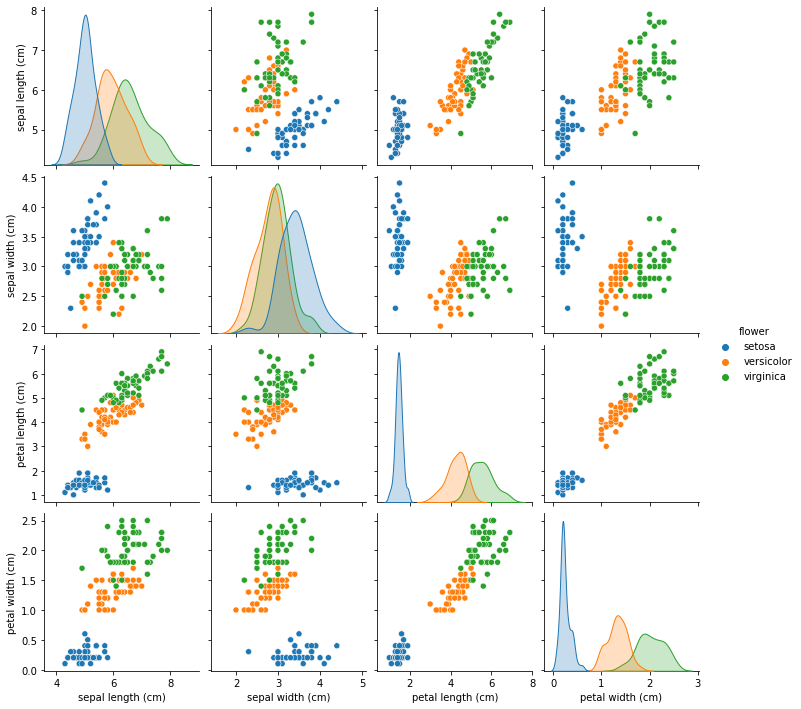

In [10]:
sns.pairplot(df,hue='flower');

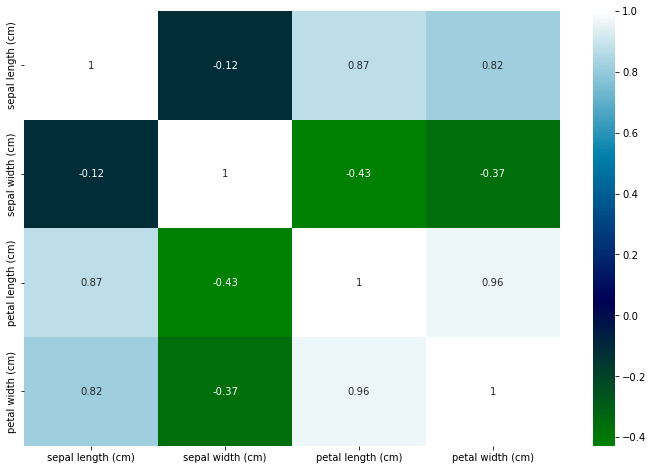

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='ocean');

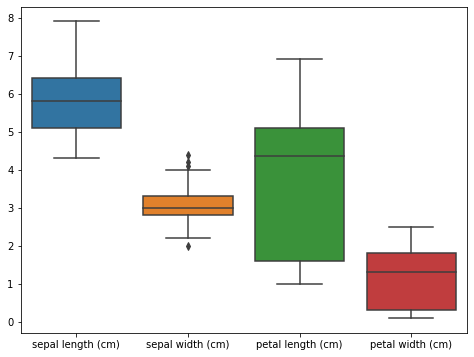

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df);

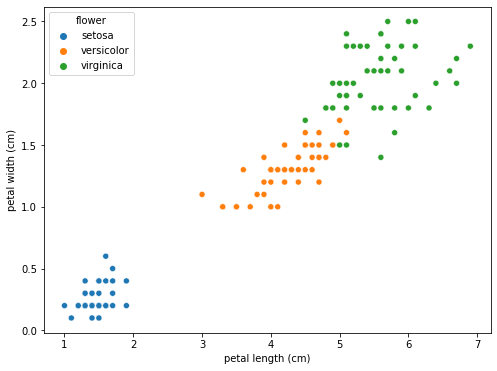

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='petal length (cm)',y='petal width (cm)',data=df,hue='flower');

In [14]:
df["petal_ratio"] = (
    df["petal length (cm)"] /
    df["petal width (cm)"]
)

df["sepal_ratio"] = (
    df["sepal length (cm)"] /
    df["sepal width (cm)"]
)

df["total_length"] = (
    df["sepal length (cm)"] +
    df["petal length (cm)"]
)

df["total_width"] = (
    df["sepal width (cm)"] +
    df["petal width (cm)"]
)

In [15]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower,petal_ratio,sepal_ratio,total_length,total_width
0,5.1,3.5,1.4,0.2,setosa,7.0,1.457143,6.5,3.7
1,4.9,3.0,1.4,0.2,setosa,7.0,1.633333,6.3,3.2
2,4.7,3.2,1.3,0.2,setosa,6.5,1.468750,6.0,3.4
3,4.6,3.1,1.5,0.2,setosa,7.5,1.483871,6.1,3.3
4,5.0,3.6,1.4,0.2,setosa,7.0,1.388889,6.4,3.8


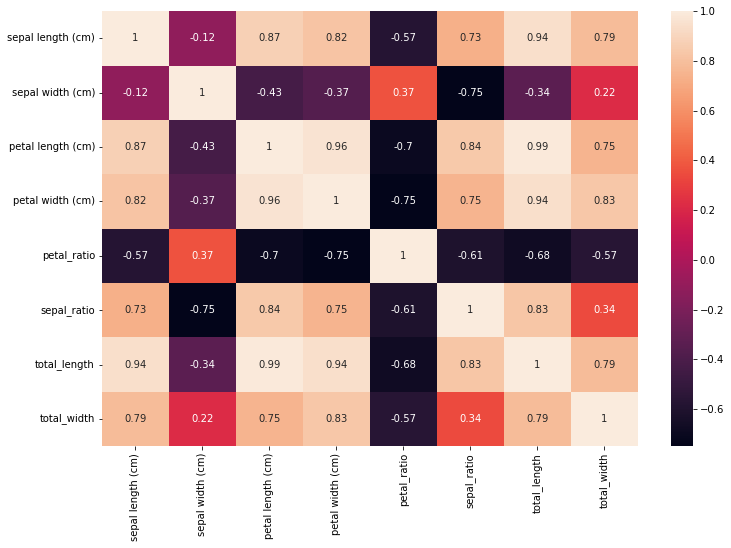

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True);

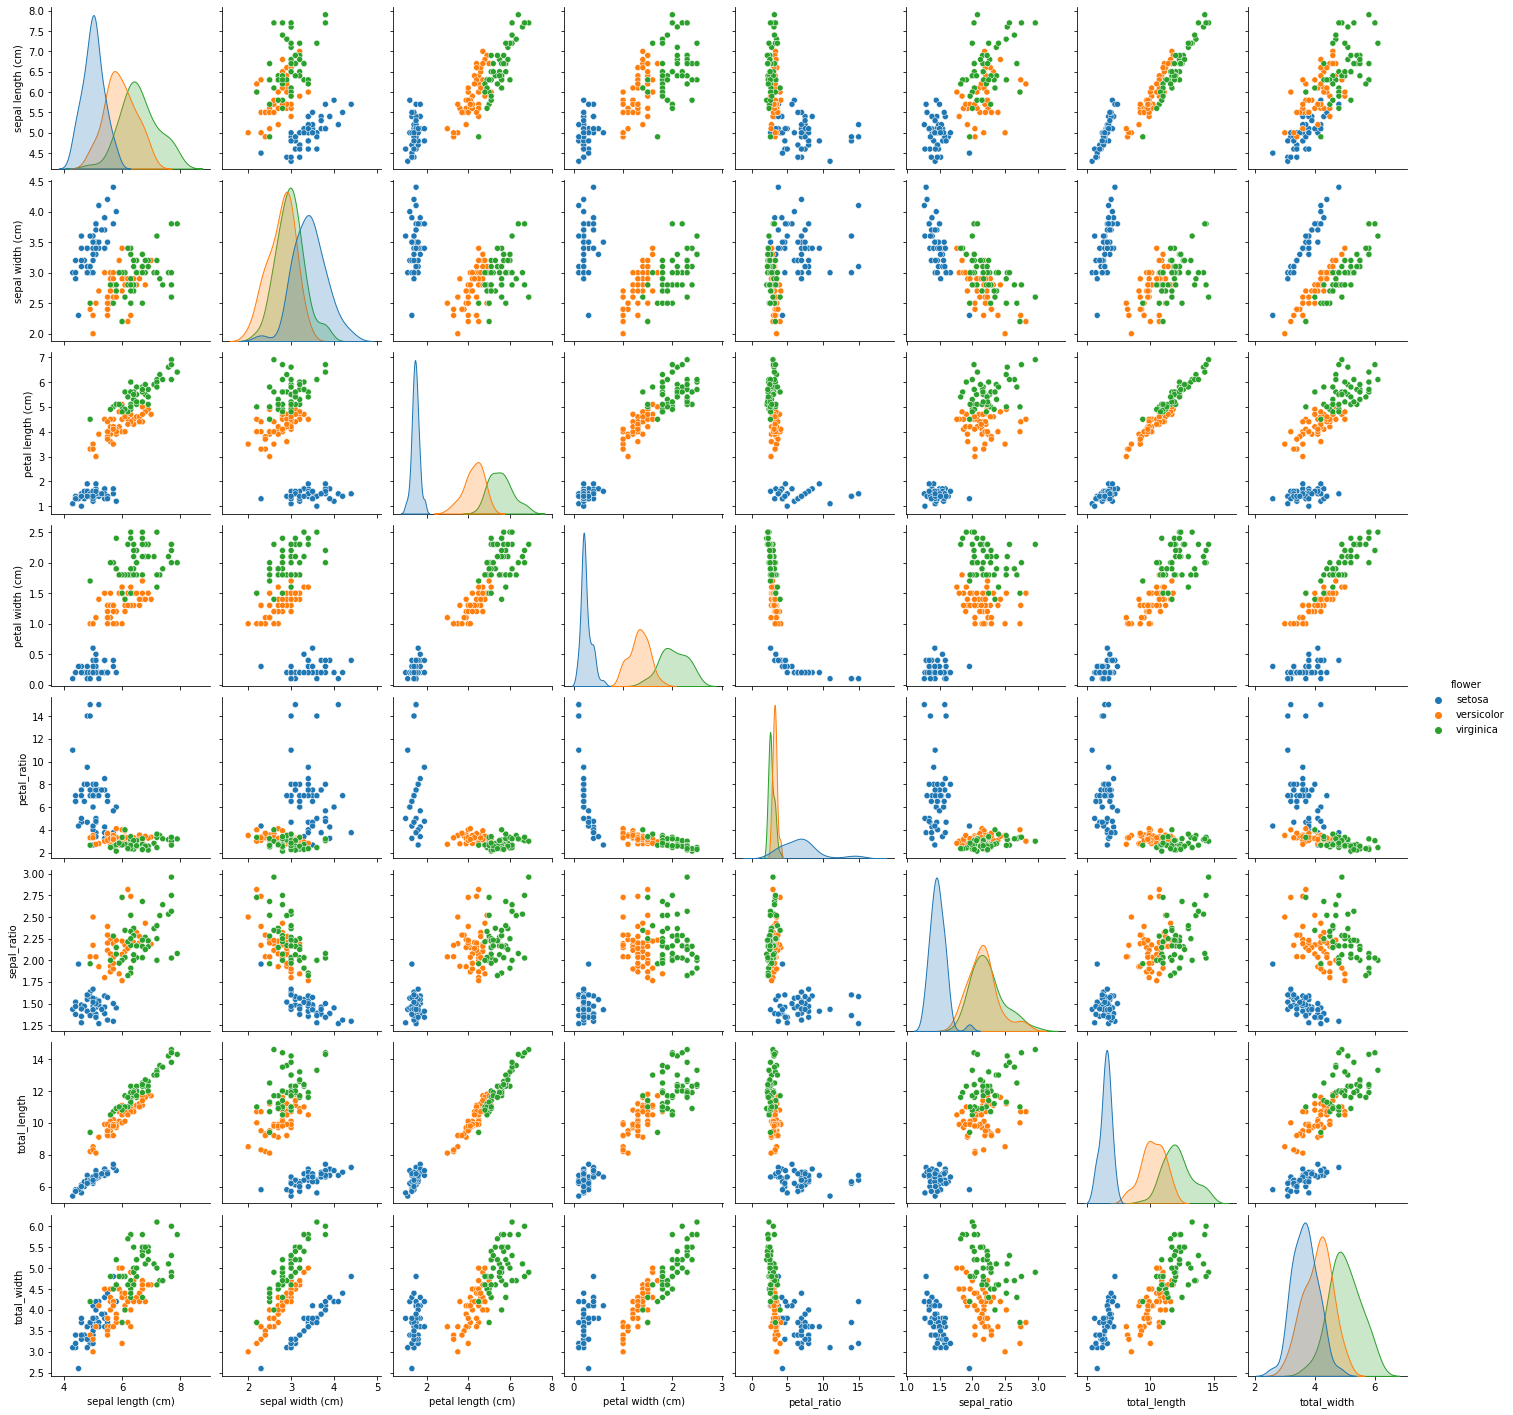

In [17]:
sns.pairplot(df,hue='flower');

In [26]:
X=df.drop(['flower'],axis=1)
y=df[['flower']]

from sklearn.model_selection import train_test_split,cross_val_score
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
sc.fit(X_train)
X_train_scaled=sc.transform(X_train)
X_test_scaled=sc.transform(X_test)

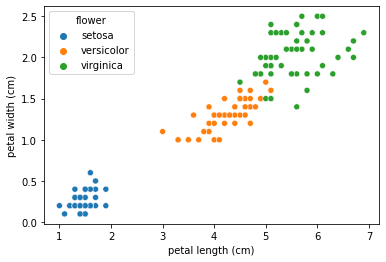

In [20]:
sns.scatterplot(df['petal length (cm)'],df['petal width (cm)'],hue='flower',data=df);

### Random Forest Model

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [22]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
y_pred=rf.predict(X_test)


In [27]:
cv_scores=cross_val_score(
    rf,
    X,
    y,
    cv=10
)

print("CV Scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

CV Scores:
[1.         0.93333333 1.         0.93333333 0.93333333 0.93333333
 0.86666667 1.         1.         1.        ]

Mean CV Accuracy:
0.96


In [28]:
from sklearn.metrics import accuracy_score, classification_report


acc=accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [29]:
import matplotlib.pyplot as plt


feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)


             Feature  Importance
2  petal length (cm)    0.294447
3   petal width (cm)    0.230872
6       total_length    0.145781
5        sepal_ratio    0.095197
4        petal_ratio    0.093459
7        total_width    0.073046
0  sepal length (cm)    0.050374
1   sepal width (cm)    0.016825


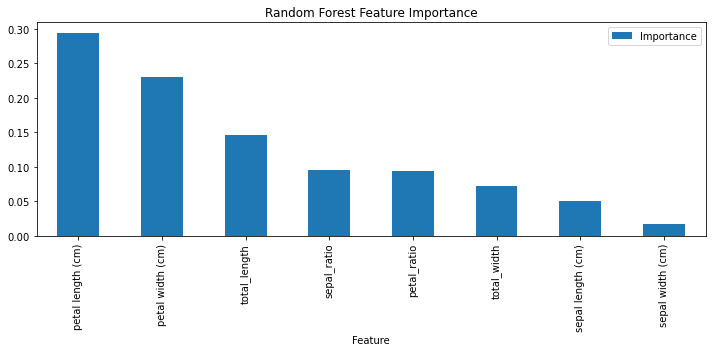

In [30]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [31]:
import joblib

joblib.dump(rf, "iris_rf_model.pkl")

['iris_rf_model.pkl']